# Phase 05 — Dataset building and evidence report

Notebook chỉ lưu output ở cell cuối cùng, sau khi toàn bộ report và biểu đồ đã hiển thị để review.

In [1]:
from pathlib import Path
import sys
from IPython.display import display

def root(start):
    for p in [start, *start.parents]:
        if (p / 'data').is_dir() and (p / 'notebooks').is_dir(): return p
    raise FileNotFoundError('Không tìm thấy project root.')

PROJECT_ROOT = root(Path.cwd().resolve())
sys.path.insert(0, str(PROJECT_ROOT))
print('Project root:', PROJECT_ROOT)
print('Review results first; save only in the final cell.')

Project root: C:\Users\ADMIN\ENVI-IT-MT
Review results first; save only in the final cell.


In [2]:
from tools.build_phase05_dataset import prepare_phase05_evidence, create_figures

evidence = prepare_phase05_evidence()
figures = create_figures(evidence['attrition'], evidence['distribution'], evidence['dataset'])
display(evidence['dataset'][['dataset_row_id', 'split', 'source_short_name', 'it_subdomain', 'en_clean', 'vi_clean']].head())
evidence['report']

,dataset_row_id,split,source_short_name,it_subdomain,en_clean,vi_clean
0,e7595b6b7fcb3ef711cb475225357e7be8c73aa3d46037...,train,envitech_reasoning,ai_ml,The boolean expression returns true if both co...,Biểu thức boolean trả về true nếu cả hai điều ...
1,9e89c54f6206928f34b5cd56b7aee1948c591644ac4340...,train,envitech_reasoning,coding;hardware;command_cli,The 'if-else' statement controls the program f...,Câu lệnh 'if-else' kiểm soát luồng chương trình.
2,9477ace6e8e14452b41d52b54f69e152b1325f88189ab0...,train,envitech_reasoning,ai_ml,Implement a loop that runs exactly five times.,Triển khai một vòng lặp chạy chính xác năm lần.
3,1e34d1e0efe85f5deccedee49bdcfc57fe270a728dc2b0...,train,envitech_reasoning,coding,The function returns null if no match is found.,Hàm trả về null nếu không tìm thấy kết quả phù...
4,03ba463aa16146d698d30fa2931a6a1492ebfd146600ec...,train,envitech_reasoning,command_cli,Use a 'switch' statement for multiple conditio...,Sử dụng câu lệnh 'switch' cho nhiều nhánh điều...


{'dataset_schema_version': '1.1',
 'dataset_version': 'it_en_vi_v1',
 'prepared_at_utc': '2026-08-31T16:19:51.878009+00:00',
 'split_seed': 42,
 'split_ratios_target': {'train': 0.8, 'validation': 0.1, 'it_test': 0.1},
 'input_approved_rows': 138479,
 'global_exact_duplicates_removed': 340,
 'rows_after_global_deduplication': 138139,
 'split_counts': {'train': 110452, 'validation': 13836, 'it_test': 13851},
 'leakage_check': {'ngram_size': 5,
  'normalized_exact_pair_overlap': {'validation': 0, 'it_test': 0},
  'english_leakage_group_overlap': {'validation': 0, 'it_test': 0},
  'train_ngram_overlap': {'validation': {'shared_unique_5grams': 6330,
    'evaluation_unique_5grams': 87789,
    'percentage_of_evaluation_5grams_seen_in_train': 7.2105},
   'it_test': {'shared_unique_5grams': 6203,
    'evaluation_unique_5grams': 86836,
    'percentage_of_evaluation_5grams_seen_in_train': 7.1434}}},
 'source_inputs': [{'source_short_name': 'envitech_reasoning',
   'approved_rows': 6696,
   'it_f

## Corpus profiling report

In [3]:
display(evidence['profile'])

,split,source_short_name,primary_subdomain,pairs,en_chars_mean,vi_chars_mean,en_tokens_mean,vi_tokens_mean,length_ratio_vi_over_en_mean,en_vocab_size,vi_vocab_size,en_type_token_ratio,vi_type_token_ratio
0,it_test,envitech_reasoning,ai_ml,331,67.873112,75.921450,10.691843,16.809668,1.139296,1140,931,0.322125,0.167326
1,it_test,envitech_reasoning,coding,136,65.816176,69.360294,10.007353,15.360294,1.054641,562,588,0.412932,0.281474
2,it_test,envitech_reasoning,command_cli,12,58.916667,67.666667,9.333333,14.333333,1.158600,84,128,0.750000,0.744186
3,it_test,envitech_reasoning,documentation,4,67.250000,78.250000,11.000000,17.000000,1.165694,34,56,0.772727,0.823529
4,it_test,envitech_reasoning,hardware,121,73.504132,76.314050,10.933884,17.181818,1.040139,493,496,0.372638,0.238576
...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,validation,ubuntu,command_cli,13,31.000000,34.846154,5.000000,7.230769,1.162769,47,70,0.723077,0.744681
87,validation,ubuntu,documentation,3,31.333333,42.000000,4.666667,9.000000,1.474153,14,24,1.000000,0.888889
88,validation,ubuntu,hardware,8,29.500000,35.875000,4.625000,8.000000,1.167474,28,41,0.756757,0.640625
89,validation,ubuntu,system,37,52.756757,53.243243,8.513514,11.891892,1.005369,177,212,0.561905,0.481818


## Subdomain distribution by split

,split,primary_subdomain,pairs,split_pairs,percentage
0,it_test,ai_ml,3124,13851,22.554328
1,train,ai_ml,24910,110452,22.552783
2,validation,ai_ml,3117,13836,22.528187
3,it_test,coding,656,13851,4.736120
4,train,coding,5270,110452,4.771303
5,validation,coding,664,13836,4.799075
6,it_test,command_cli,176,13851,1.270666
7,train,command_cli,1397,110452,1.264803
8,validation,command_cli,171,13836,1.235906
9,it_test,documentation,5452,13851,39.361779


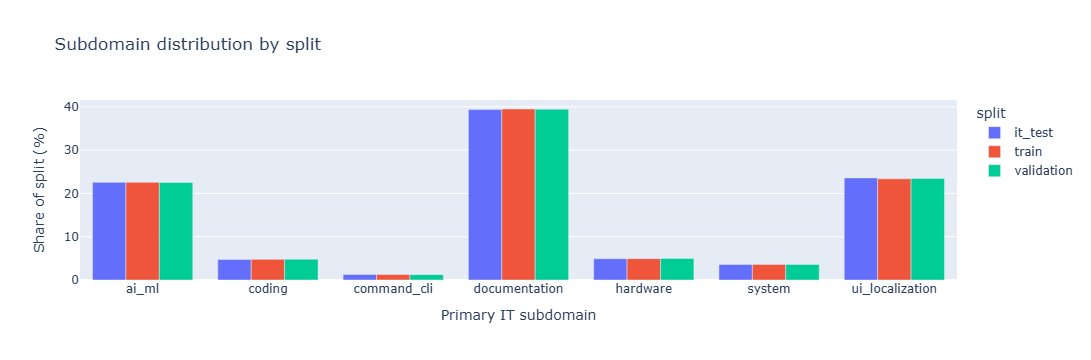

In [4]:
display(evidence['distribution'])
figures['subdomain_split_distribution'].show()

## Global exact deduplication and 5-gram leakage check

In [5]:
print('Global exact duplicates removed:', evidence['report']['global_exact_duplicates_removed'])
display(evidence['global_duplicates'].head())
evidence['leakage']

Global exact duplicates removed: 340


,source_short_name,raw_row_index,en_raw,vi_raw,en_clean,vi_clean,pair_sha256,audit_flags,audit_flag_list,auto_reject_audit_flags,...,it_subdomain,classification_method,it_decision,decision_reason,manual_review_note,en_match_key,vi_match_key,global_pair_key,source_order,phase_05_rejection_reason
1015,envitech_reasoning,1853,Natural Language Processing (NLP) enables comp...,Xử lý Ngôn ngữ Tự nhiên (NLP) cho phép máy tín...,Natural Language Processing (NLP) enables comp...,Xử lý Ngôn ngữ Tự nhiên (NLP) cho phép máy tín...,a074b33037277ab143a412879c49cd6abf2be49affb6b5...,,[],[],...,system,keyword,approve,it_taxonomy_evidence,None,natural language processing (nlp) enables comp...,xử lý ngôn ngữ tự nhiên (nlp) cho phép máy tín...,natural language processing (nlp) enables comp...,0,global_exact_duplicate
2135,envitech_reasoning,3290,The latest GPU architecture features more stre...,Kiến trúc GPU mới nhất có nhiều bộ xử lý đa lu...,The latest GPU architecture features more stre...,Kiến trúc GPU mới nhất có nhiều bộ xử lý đa lu...,77043d77b432a7eca210a0297aee75554d3022eebc563a...,,[],[],...,hardware;system,keyword,approve,it_taxonomy_evidence,None,the latest gpu architecture features more stre...,kiến trúc gpu mới nhất có nhiều bộ xử lý đa lu...,the latest gpu architecture features more stre...,0,global_exact_duplicate
2665,envitech_reasoning,3941,Each Streaming Multiprocessor (SM) contains mu...,Mỗi Bộ xử lý đa luồng (SM) chứa nhiều lõi CUDA.,Each Streaming Multiprocessor (SM) contains mu...,Mỗi Bộ xử lý đa luồng (SM) chứa nhiều lõi CUDA.,dbbbdf3c86808a2ab52b1a01f6e7f1001275551e6aee10...,,[],[],...,ai_ml;system,keyword,approve,it_taxonomy_evidence,None,each streaming multiprocessor (sm) contains mu...,mỗi bộ xử lý đa luồng (sm) chứa nhiều lõi cuda.,each streaming multiprocessor (sm) contains mu...,0,global_exact_duplicate
2867,envitech_reasoning,4201,Each Streaming Multiprocessor (SM) contains mu...,Mỗi Bộ xử lý đa luồng (SM) chứa nhiều Lõi CUDA.,Each Streaming Multiprocessor (SM) contains mu...,Mỗi Bộ xử lý đa luồng (SM) chứa nhiều Lõi CUDA.,6bc0e63ed16522834c214e5067fd51f610baeb1aaf0b4d...,,[],[],...,ai_ml;system,keyword,approve,it_taxonomy_evidence,None,each streaming multiprocessor (sm) contains mu...,mỗi bộ xử lý đa luồng (sm) chứa nhiều lõi cuda.,each streaming multiprocessor (sm) contains mu...,0,global_exact_duplicate
5682,envitech_reasoning,9822,The observer pattern is useful for decoupling ...,Mẫu Observer hữu ích cho việc tách rời các thà...,The observer pattern is useful for decoupling ...,Mẫu Observer hữu ích cho việc tách rời các thà...,4f48e00c6cd3f04eb29a0d2f9fe547762f790f84d4b126...,,[],[],...,system,keyword,approve,it_taxonomy_evidence,None,the observer pattern is useful for decoupling ...,mẫu observer hữu ích cho việc tách rời các thà...,the observer pattern is useful for decoupling ...,0,global_exact_duplicate


{'ngram_size': 5,
 'normalized_exact_pair_overlap': {'validation': 0, 'it_test': 0},
 'english_leakage_group_overlap': {'validation': 0, 'it_test': 0},
 'train_ngram_overlap': {'validation': {'shared_unique_5grams': 6330,
   'evaluation_unique_5grams': 87789,
   'percentage_of_evaluation_5grams_seen_in_train': 7.2105},
  'it_test': {'shared_unique_5grams': 6203,
   'evaluation_unique_5grams': 86836,
   'percentage_of_evaluation_5grams_seen_in_train': 7.1434}}}

## Data attrition funnel and Sankey

,stage,pairs
0,RAW collected,163869
1,After rule-based cleaning,159220
2,After IT filtering,138479
3,After global exact deduplication,138139


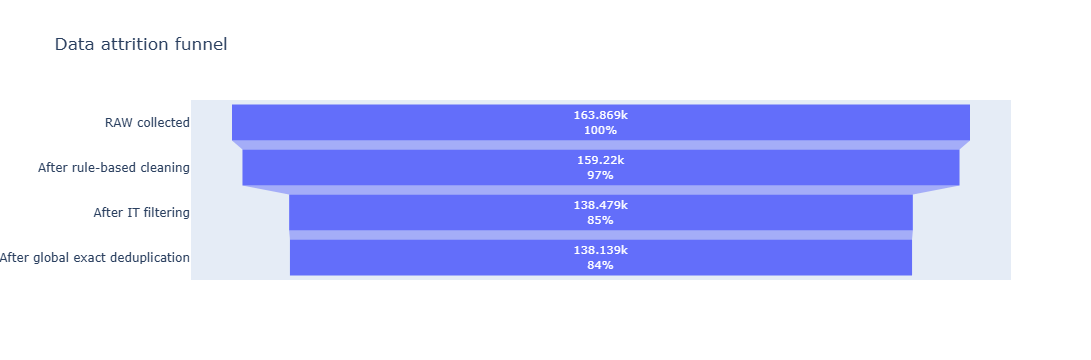

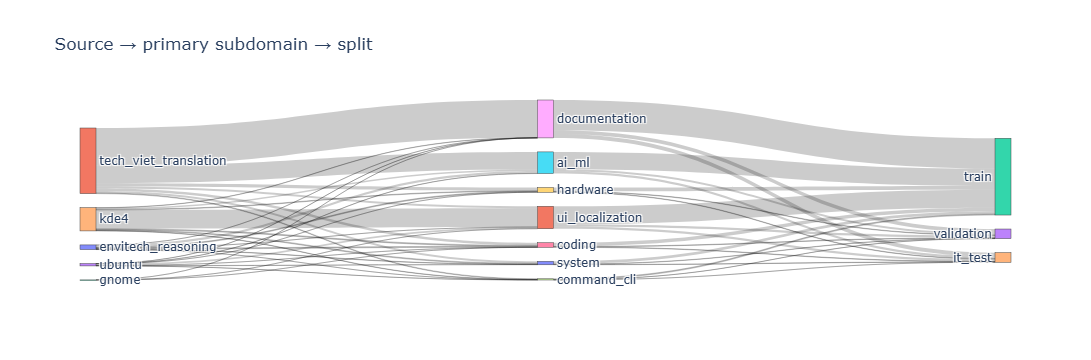

In [6]:
display(evidence['attrition'])
figures['data_attrition_funnel'].show()
figures['source_subdomain_split_sankey'].show()

## Human-validation worksheet — head(5)

Mẫu này chỉ minh họa, không đủ để ước lượng precision. Điền ba cột reviewer sau khi export.

In [7]:
display(evidence['human_sample'])

,dataset_row_id,split,source_short_name,it_subdomain,en_clean,vi_clean,reviewer_it_relevant,reviewer_translation_aligned,reviewer_notes
92167,00002551b2afaa45b3d2bda4ab0ce101b5b4cd97451246...,train,tech_viet_translation,ai_ml;hardware,Black Friday Tech Deals Live: Latest PC hardwa...,Ưu đãi công nghệ Thứ Sáu Đen trực tiếp: Doanh ...,,,
117958,0000a4dce19ef688b86d08f6d1e9a6f3c02d0ec6017957...,train,kde4,coding,Encoding,Bộ ký tự,,,
64654,00010b84c19ab190d747a0f98941e3bf61c06e67d37c58...,train,tech_viet_translation,documentation,ESA finds Martian water reservoir that’s two-m...,ESA tìm thấy hồ chứa nước sao Hỏa sâu 2 dặm,,,
58593,00011c5a39e4f82f3391d4b3e475b7517b43cd57c068e0...,train,tech_viet_translation,ui_localization,These new iPhone screen protector kits make ap...,Những bộ bảo vệ màn hình iPhone mới này giúp v...,,,
122110,00016db7c01ad957de0ae3a4383c7744dd51dbe1f7eae9...,train,kde4,ui_localization,You did not provide a backup suffix or prefix....,Bạn chưa cung cấp hậu tố hoặc tiền tố sao lưu ...,,,


## Save after review

Cell duy nhất ghi file: dataset tại `data/processed/it_en_vi_v1/`; report tại `data/final_report/it_en_vi_v1/`.

In [8]:
from tools.build_phase05_dataset import save_phase05_outputs
saved = save_phase05_outputs(evidence, figures)
saved

{'dataset_manifest': WindowsPath('C:/Users/ADMIN/ENVI-IT-MT/data/processed/it_en_vi_v1/dataset_manifest.json'),
 'final_report_manifest': WindowsPath('C:/Users/ADMIN/ENVI-IT-MT/data/final_report/it_en_vi_v1/final_report_manifest.json')}